# 25 — Comorbidity Co-Occurrence + Pulmonary Disease × Diabetes Management

**Purpose**: Three related analyses:
1. **Comorbidity co-occurrence** (Sections 1–2): Which diseases most commonly co-occur with diabetes across severity groups? Full prevalence table + pairwise Phi-coefficient co-occurrence matrix for all 29 `mhoccur_*` conditions.
2. **Pulmonary disease flag + asthma verification** (Section 3): Extract `mhoccur_plm` (pulmonary disease) as primary proxy, then cross-reference `condition_occurrence.csv` for ICD-10 asthma codes (J45.x) to determine what fraction of pulmonary cases are specifically asthma.
3. **Pulmonary × diabetes management** (Sections 4–6): Compare CGM outcomes, HbA1c, management adherence, and SDOH between pulmonary and non-pulmonary participants — especially within medicated groups (boss task #8: management of diabetes among people with vs without asthma/pulmonary disease).

**Background**: The diabetes–asthma comorbidity is clinically significant. Shared mechanisms include corticosteroid use (raises glucose), beta-agonist effects on insulin resistance, and shared inflammatory pathways. AI-READI has `mhoccur_plm` (pulmonary disease) as a binary flag for the full spectrum of lung conditions.

**Inputs**:
- Azure: `observation.csv` (for `mhoccur_*` binary flags — same pattern as NB07)
- Azure: `condition_occurrence.csv` (for asthma ICD/SNOMED code verification)
- Azure: `participants.tsv`
- Google Drive: `features_with_cluster.csv`, `13_hba1c_per_person.csv`

**Outputs**: `24_comorbidity_prevalence.csv`, `24_cooccurrence_matrix.csv`, `24_pulmonary_diabetes_summary.csv`

**Runtime**: Designed for Cursor IDE with Colab kernel, or Google Colab directly.

In [1]:
# ── 1. Environment Setup ───────────────────────────────────────────
import subprocess, sys

packages = ['azure-storage-blob', 'scipy', 'seaborn']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import os, getpass, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from io import StringIO
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_GROUP_ORDER = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP   = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
STUDY_GROUP_PAL   = dict(zip(STUDY_GROUP_ORDER, sns.color_palette('Set2', 4)))

STUDY_GROUP_STR_MAP = {
    'healthy': 0, 'prediabetes': 1, 'pre-diabetes': 1, 'pre_diabetes': 1,
    'pre_diabetes_lifestyle_controlled': 1,
    'oral medication': 2, 'oral_medication': 2, 'non-insulin': 2,
    'oral_medication_and_or_non_insulin_injectable_medication_controlled': 2,
    'insulin': 3, 'insulin-dependent': 3, 'insulin_dependent': 3,
}

STUDY_ID       = '00b62456-0b93-4975-a992-42ba6a50ed5c'
CONTAINER_NAME = 'aireadi-raw'

# Human-readable labels for mhoccur_* keys (from NB05)
MHOCCUR_LABELS = {
    'mhoccur_hbp':  'Hypertension', 'mhoccur_clsh': 'High Cholesterol',
    'mhoccur_obs':  'Obesity',       'mhoccur_crt':  'Cataracts',
    'mhoccur_ded':  'Dry Eye',       'mhoccur_glc':  'Glaucoma',
    'mhoccur_amd':  'AMD',           'mhoccur_pdr':  'Diabetic Retinopathy',
    'mhoccur_oa':   'Osteoarthritis','mhoccur_lbp':  'Low Back Pain',
    'mhoccur_ear':  'Hearing Impairment','mhoccur_gi': 'GI Disorder',
    'mhoccur_ca':   'Cancer',        'mhoccur_mi':   'Myocardial Infarction',
    'mhoccur_strk': 'Stroke',        'mhoccur_ra':   'Rheumatoid Arthritis',
    'mhoccur_rvo':  'Retinal Vascular Occlusion',
    'mhoccur_ua':   'Urinary Disorder','mhoccur_cogn': 'Cognitive Impairment',
    'mhoccur_rnl':  'Renal Disease', 'mhoccur_cvdot': 'Other CVD',
    'mhoccur_plm':  'Pulmonary Disease','mhoccur_pd':  'Parkinson Disease',
    'mhoccur_ad':   'Alzheimer Disease','mhoccur_ms':  'Multiple Sclerosis',
    'mhoccur_circ': 'Circulatory Disorder','mhoccur_cns': 'Other CNS',
    'mhoccur_yn':   'Other Comorbidity','mhoccur_fall': 'Falls History',
}

print('Environment ready.')

Environment ready.


In [2]:
# ── 2. Google Drive Mount ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
out_dir = Path('/content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs')
out_dir.mkdir(parents=True, exist_ok=True)
print(f'Output directory: {out_dir}')

Mounted at /content/drive
Output directory: /content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs


In [3]:
# ── 3. Azure Connection ────────────────────────────────────────────
from azure.storage.blob import BlobServiceClient

IN_COLAB = os.path.exists('/content')
if IN_COLAB:
    print('Paste your Azure CONNECTION_STRING when prompted:')
    CONNECTION_STRING = getpass.getpass('CONNECTION_STRING: ')
else:
    repo_root = os.path.abspath('..')
    if repo_root not in sys.path:
        sys.path.insert(0, repo_root)
    from config.azure_config import CONNECTION_STRING, CONTAINER_NAME

blob_svc  = BlobServiceClient.from_connection_string(CONNECTION_STRING)
container = blob_svc.get_container_client(CONTAINER_NAME)

def load_blob_csv(blob_path, sep=',', **kwargs):
    bc   = container.get_blob_client(blob_path)
    data = bc.download_blob().readall().decode('utf-8')
    return pd.read_csv(StringIO(data), sep=sep, low_memory=False, **kwargs)

print('Azure connection established.')

Paste your Azure CONNECTION_STRING when prompted:
Azure connection established.


In [4]:
# ── 4. Load observation.csv and parse mhoccur_* (mirrors NB07) ────
print('Loading participants.tsv...')
participants = load_blob_csv(f'{STUDY_ID}/dataset/participants.tsv', sep='\t')
participants['study_group_code'] = (participants['study_group'].str.lower()
                                     .str.strip().map(STUDY_GROUP_STR_MAP))
participants['study_group_label'] = participants['study_group_code'].map(STUDY_GROUP_MAP)
participants['person_id'] = participants['person_id'].astype(str)
print(f'Participants: {len(participants):,}')
print(participants['study_group_label'].value_counts().to_string())

print('\nLoading observation.csv (~108 MB)...')
obs_raw = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/observation.csv')
print(f'Observations: {obs_raw.shape}')

# Parse item_key (same pattern as NB07)
obs_raw['item_key'] = (obs_raw['observation_source_value']
                       .astype(str).str.split(',', n=1).str[0]
                       .str.strip().str.lower())
obs_raw['value_clean'] = pd.to_numeric(obs_raw['value_as_number'], errors='coerce')
obs_raw.loc[obs_raw['value_clean'] == 99, 'value_clean'] = np.nan
obs_raw['person_id'] = obs_raw['person_id'].astype(str)
print(f'Unique item keys: {obs_raw["item_key"].nunique():,}')

Loading participants.tsv...
Participants: 2,280
study_group_label
Healthy     776
Oral Med    686
Pre-DM      560
Insulin     258

Loading observation.csv (~108 MB)...
Observations: (707126, 22)
Unique item keys: 361


In [5]:
# ── 4b. Extract mhoccur_* binary flags ────────────────────────────
mh_keys = [k for k in obs_raw['item_key'].unique()
           if k.startswith('mhoccur') and k != 'mhoccur_fallot']
print(f'Comorbidity binary keys: {len(mh_keys)}')
print(mh_keys)

mh_long = obs_raw[obs_raw['item_key'].isin(mh_keys)][
    ['person_id', 'item_key', 'value_clean']]
mh_wide = (mh_long.pivot_table(index='person_id', columns='item_key',
                                values='value_clean', aggfunc='mean')
           .clip(upper=1)
           .reindex(participants['person_id'], fill_value=0))
mh_wide.columns.name = None

# Merge study group
mh_wide = mh_wide.reset_index()
mh_wide = mh_wide.merge(
    participants[['person_id', 'study_group_code', 'study_group_label']],
    on='person_id', how='left')
mh_wide['study_group_label'] = pd.Categorical(
    mh_wide['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)

print(f'\nComorbidity binary table: {mh_wide.shape}')
print(f'mhoccur_plm present: {"mhoccur_plm" in mh_wide.columns}')

Comorbidity binary keys: 29
['mhoccur_mi', 'mhoccur_cvdot', 'mhoccur_strk', 'mhoccur_clsh', 'mhoccur_hbp', 'mhoccur_ua', 'mhoccur_ear', 'mhoccur_pdr', 'mhoccur_circ', 'mhoccur_lbp', 'mhoccur_pd', 'mhoccur_ad', 'mhoccur_cogn', 'mhoccur_ms', 'mhoccur_cns', 'mhoccur_ra', 'mhoccur_oa', 'mhoccur_ca', 'mhoccur_plm', 'mhoccur_gi', 'mhoccur_rnl', 'mhoccur_obs', 'mhoccur_glc', 'mhoccur_amd', 'mhoccur_crt', 'mhoccur_rvo', 'mhoccur_ded', 'mhoccur_yn', 'mhoccur_fall']

Comorbidity binary table: (2280, 32)
mhoccur_plm present: True


## Section 1: Comorbidity Prevalence by Study Group

In [6]:
# ── 1a. Prevalence table: all conditions × study group ─────────────
binary_cols = [c for c in mh_keys if c in mh_wide.columns]
n_per_group = mh_wide.groupby('study_group_label', observed=True).size()

prev_rows = []
for col in binary_cols:
    row = {'condition': MHOCCUR_LABELS.get(col, col), 'key': col}
    row['overall_pct'] = round(mh_wide[col].mean() * 100, 1)
    row['overall_n']   = int(mh_wide[col].sum())
    for grp in STUDY_GROUP_ORDER:
        sub = mh_wide[mh_wide['study_group_label'] == grp][col]
        row[f'{grp}_pct'] = round(sub.mean() * 100, 1)
    prev_rows.append(row)

prev_df = pd.DataFrame(prev_rows).sort_values('overall_pct', ascending=False)
print('=== Comorbidity Prevalence (%) by Study Group ===\n')
print(prev_df.to_string(index=False))

prev_df.to_csv(out_dir / '24_comorbidity_prevalence.csv', index=False)
print('\nSaved 24_comorbidity_prevalence.csv')

=== Comorbidity Prevalence (%) by Study Group ===

                 condition           key  overall_pct  overall_n  Healthy_pct  Pre-DM_pct  Oral Med_pct  Insulin_pct
          High Cholesterol  mhoccur_clsh       51.100       1164       38.400      48.800        63.400       61.200
              Hypertension   mhoccur_hbp       50.700       1157       32.700      46.600        65.600       74.400
      Rheumatoid Arthritis    mhoccur_ra       41.800        952       33.400      41.600        48.100       50.400
                   Obesity   mhoccur_obs       38.600        879       25.300      38.200        48.400       53.100
                   Dry Eye   mhoccur_ded       32.900        750       28.600      34.600        35.300       35.700
                 Cataracts   mhoccur_crt       31.000        706       27.700      27.900        33.200       41.500
         Other Comorbidity    mhoccur_yn       25.400        580       26.300      27.100        24.300       22.100
             

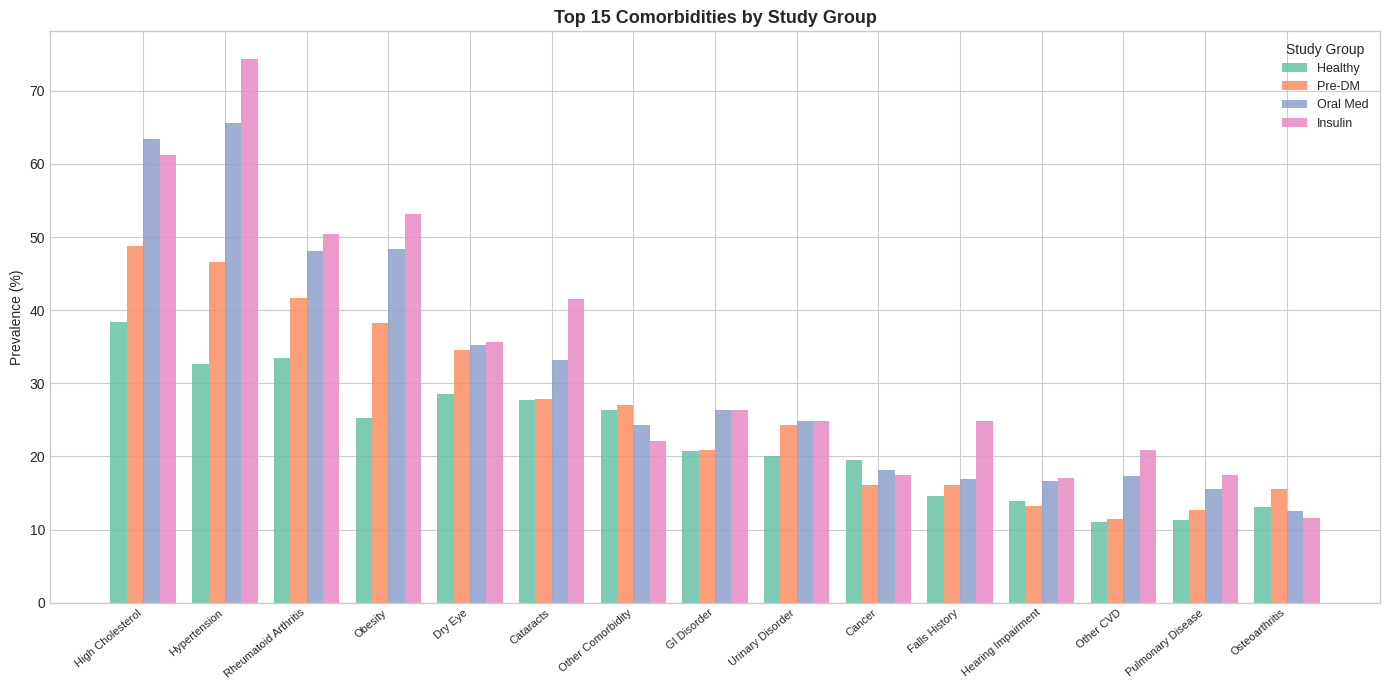


=== Chi-square: Condition × Study Group ===
Condition                           Chi2           p  sig
----------------------------------------------------------
Myocardial Infarction              52.32  2.5651e-11  ***
Other CVD                          24.94  1.5929e-05  ***
Stroke                             16.50  8.9557e-04  ***
High Cholesterol                  103.53  2.7069e-22  ***
Hypertension                      222.97  4.5763e-48  ***
Urinary Disorder                    5.89  1.1732e-01  ns
Hearing Impairment                  4.38  2.2290e-01  ns
Circulatory Disorder               14.00  2.9112e-03  **
Low Back Pain                       3.95  2.6736e-01  ns
Cognitive Impairment               10.01  1.8512e-02  *
Other CNS                           9.60  2.2255e-02  *
Rheumatoid Arthritis               41.68  4.6808e-09  ***
Osteoarthritis                      3.39  3.3561e-01  ns
Cancer                              2.59  4.5950e-01  ns
Pulmonary Disease                   

In [7]:
# ── 1b. Bar chart: top 15 conditions by study group ────────────────
top15 = prev_df.head(15)['key'].tolist()

fig, ax = plt.subplots(figsize=(14, 7))

x     = np.arange(len(top15))
width = 0.2
for i, grp in enumerate(STUDY_GROUP_ORDER):
    vals = [prev_df[prev_df['key'] == c][f'{grp}_pct'].values[0] for c in top15]
    ax.bar(x + i * width, vals, width, label=grp,
           color=STUDY_GROUP_PAL[grp], alpha=0.85)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(
    [MHOCCUR_LABELS.get(c, c) for c in top15],
    rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Prevalence (%)')
ax.set_title('Top 15 Comorbidities by Study Group', fontsize=13, fontweight='bold')
ax.legend(title='Study Group', fontsize=9)
plt.tight_layout()
plt.show()

# Chi-square tests: condition × study group
print('\n=== Chi-square: Condition × Study Group ===')
print(f'{"Condition":<30}  {"Chi2":>8}  {"p":>10}  sig')
print('-' * 58)
chi2_rows = []
for col in binary_cols:
    ct = pd.crosstab(mh_wide['study_group_label'], mh_wide[col])
    if ct.shape == (4, 2) and ct.min().min() >= 5:
        chi2, p, dof, _ = stats.chi2_contingency(ct)
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        label = MHOCCUR_LABELS.get(col, col)
        print(f'{label:<30}  {chi2:>8.2f}  {p:>10.4e}  {sig}')
        chi2_rows.append({'condition': label, 'key': col, 'chi2': round(chi2, 3),
                          'p': round(p, 6), 'sig': sig})

## Section 2: Co-Occurrence Matrix

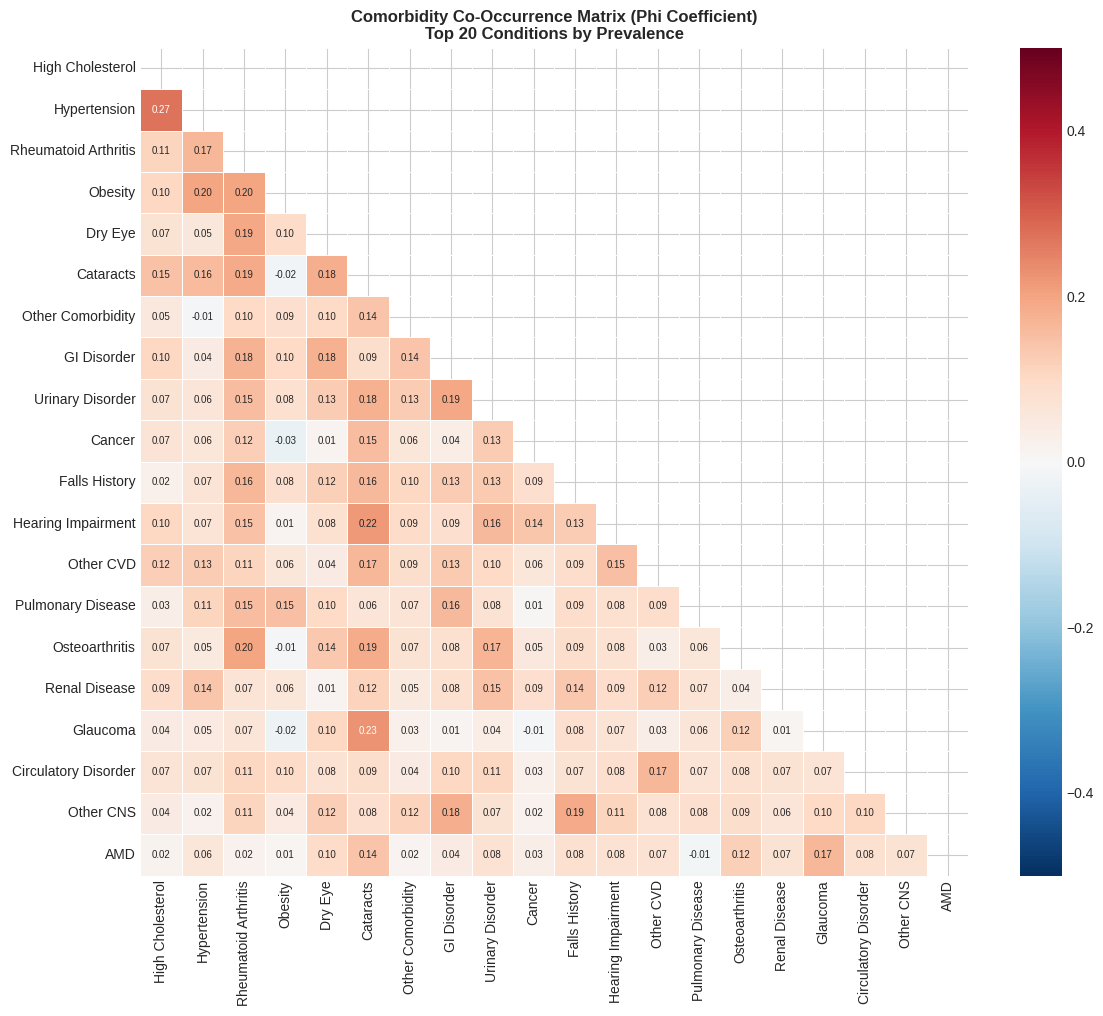

Saved 24_cooccurrence_matrix.csv


In [8]:
# ── 2a. Phi-coefficient co-occurrence matrix ───────────────────────
# Phi = (n11*n00 - n10*n01) / sqrt((n11+n10)*(n01+n00)*(n11+n01)*(n10+n00))
# For binary × binary this is equivalent to Pearson r

top20_cols = prev_df.head(20)['key'].tolist()
top20_cols = [c for c in top20_cols if c in mh_wide.columns]

phi_matrix = mh_wide[top20_cols].corr(method='pearson')
phi_matrix.index   = [MHOCCUR_LABELS.get(c, c) for c in top20_cols]
phi_matrix.columns = [MHOCCUR_LABELS.get(c, c) for c in top20_cols]

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(phi_matrix, dtype=bool))
sns.heatmap(phi_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-0.5, vmax=0.5,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Comorbidity Co-Occurrence Matrix (Phi Coefficient)\n'
             'Top 20 Conditions by Prevalence',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

phi_matrix.to_csv(out_dir / '24_cooccurrence_matrix.csv')
print('Saved 24_cooccurrence_matrix.csv')

In [9]:
# ── 2b. Most common disease pairs in insulin-dependent group ───────
insulin_group = mh_wide[mh_wide['study_group_label'] == 'Insulin'][binary_cols]

pair_rows = []
from itertools import combinations
for c1, c2 in combinations(binary_cols, 2):
    n_both = (insulin_group[c1] * insulin_group[c2]).sum()
    n_total = len(insulin_group)
    pct = n_both / n_total * 100
    pair_rows.append({
        'cond1': MHOCCUR_LABELS.get(c1, c1),
        'cond2': MHOCCUR_LABELS.get(c2, c2),
        'n_both': int(n_both),
        'pct_both': round(pct, 1)
    })

top_pairs = pd.DataFrame(pair_rows).sort_values('pct_both', ascending=False).head(20)
print('=== Top 20 Co-Occurring Disease Pairs in Insulin Group ===\n')
print(top_pairs.to_string(index=False))

=== Top 20 Co-Occurring Disease Pairs in Insulin Group ===

               cond1                cond2  n_both  pct_both
    High Cholesterol         Hypertension     136    52.700
        Hypertension              Obesity     106    41.100
        Hypertension Rheumatoid Arthritis     105    40.700
    High Cholesterol              Obesity      91    35.300
    High Cholesterol Rheumatoid Arthritis      90    34.900
        Hypertension            Cataracts      90    34.900
Rheumatoid Arthritis              Obesity      77    29.800
        Hypertension              Dry Eye      73    28.300
    High Cholesterol            Cataracts      73    28.300
    High Cholesterol              Dry Eye      64    24.800
Rheumatoid Arthritis            Cataracts      63    24.400
        Hypertension        Renal Disease      60    23.300
Rheumatoid Arthritis              Dry Eye      56    21.700
        Hypertension          GI Disorder      54    20.900
             Obesity            Cataract

## Section 3: Pulmonary Disease Flag + Asthma Verification

In [10]:
# ── 3a. mhoccur_plm prevalence ─────────────────────────────────────
PLM_COL = 'mhoccur_plm'

if PLM_COL in mh_wide.columns:
    print('=== Pulmonary Disease (mhoccur_plm) Prevalence ===\n')
    overall_pct = mh_wide[PLM_COL].mean() * 100
    print(f'Overall: {mh_wide[PLM_COL].sum():.0f} / {len(mh_wide):,} ({overall_pct:.1f}%)')
    print()
    for grp in STUDY_GROUP_ORDER:
        sub = mh_wide[mh_wide['study_group_label'] == grp]
        n   = sub[PLM_COL].sum()
        pct = sub[PLM_COL].mean() * 100
        print(f'  {grp:<12}: {n:.0f} / {len(sub):,} ({pct:.1f}%)')

    # Chi-square across study groups
    ct = pd.crosstab(mh_wide['study_group_label'], mh_wide[PLM_COL])
    if ct.min().min() >= 5:
        chi2, p, *_ = stats.chi2_contingency(ct)
        print(f'\nChi-square: chi2={chi2:.2f}  p={p:.4e}')
else:
    print(f'{PLM_COL} not found in data — check mhoccur key names in obs_raw.')

=== Pulmonary Disease (mhoccur_plm) Prevalence ===

Overall: 311 / 2,280 (13.6%)

  Healthy     : 88 / 776 (11.3%)
  Pre-DM      : 71 / 560 (12.7%)
  Oral Med    : 107 / 686 (15.6%)
  Insulin     : 45 / 258 (17.4%)

Chi-square: chi2=9.32  p=2.5311e-02


In [11]:
# ── 3b. Asthma verification from condition_occurrence.csv ─────────
print('Loading condition_occurrence.csv (~1.77 MB) from Azure...')
cond = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/condition_occurrence.csv')
cond['person_id'] = cond['person_id'].astype(str)
print(f'condition_occurrence: {cond.shape}')
print('Columns:', cond.columns.tolist())
print('\nTop 20 condition_source_value entries by frequency:')
print(cond['condition_source_value'].value_counts().head(20).to_string())

Loading condition_occurrence.csv (~1.77 MB) from Azure...
condition_occurrence: (12375, 16)
Columns: ['condition_occurrence_id', 'person_id', 'condition_concept_id', 'condition_start_date', 'condition_start_datetime', 'condition_end_date', 'condition_end_datetime', 'condition_type_concept_id', 'condition_status_concept_id', 'stop_reason', 'provider_id', 'visit_occurrence_id', 'visit_detail_id', 'condition_source_value', 'condition_source_concept_id', 'condition_status_source_value']

Top 20 condition_source_value entries by frequency:
condition_source_value
mh_a1c, Elevated A1C levels (elevated blood sugar    1202
mhoccur_hbp, High blood pressure                     1151
mhoccur_clsh, High blood cholesterol                 1145
mhoccur_ra, Arthritis (joint pain)                    941
mhterm_dm2, Type II Diabetes                          899
mhoccur_obs, Obesity                                  845
mhoccur_ded, Dry eye (in one or both eyes)            741
mhoccur_crt, Cataracts (in one

In [12]:
# ── 3c. Filter for asthma ICD-10 and SNOMED codes ─────────────────
# ICD-10 asthma: J45.x (Asthma), J45.20, J45.21, J45.30, J45.40, J45.50, J45.901
# SNOMED: 195967001 (Asthma), 266361008, 57546000, etc.
# Try multiple field names

source_col = next((c for c in cond.columns
                   if 'source_value' in c.lower()), None)
concept_col = next((c for c in cond.columns
                    if 'concept_id' in c.lower() and 'source' not in c.lower()), None)

asthma_pids = set()

# Text match on source value
if source_col:
    asthma_text = cond[cond[source_col].astype(str).str.contains(
        r'J45|asthma', case=False, na=False)]
    print(f'Asthma by text match ({source_col}): {len(asthma_text):,} rows  '
          f'{asthma_text["person_id"].nunique():,} participants')
    print('Unique matched values:', asthma_text[source_col].value_counts().head(10).to_string())
    asthma_pids.update(asthma_text['person_id'].unique())

# SNOMED concept ID match
ASTHMA_SNOMED = {195967001, 266361008, 57546000, 33223000, 225057002, 304527002}
if concept_col:
    asthma_snomed = cond[cond[concept_col].isin(ASTHMA_SNOMED)]
    print(f'Asthma by SNOMED concept_id: {len(asthma_snomed):,} rows  '
          f'{asthma_snomed["person_id"].nunique():,} participants')
    asthma_pids.update(asthma_snomed['person_id'].unique())

asthma_set = asthma_pids
print(f'\nTotal unique participants with asthma codes: {len(asthma_set):,}')

# What fraction of mhoccur_plm participants have confirmed asthma codes?
if PLM_COL in mh_wide.columns:
    pulm_pids   = set(mh_wide[mh_wide[PLM_COL] == 1]['person_id'].astype(str))
    overlap     = pulm_pids & asthma_set
    pct_overlap = len(overlap) / len(pulm_pids) * 100 if pulm_pids else 0

    print(f'\n=== Asthma Verification ===')
    print(f'mhoccur_plm=1 participants:          {len(pulm_pids):,}')
    print(f'Asthma code in condition_occurrence: {len(asthma_set):,}')
    print(f'Overlap (both):                      {len(overlap):,}')
    print(f'% of pulmonary flag that is asthma:  {pct_overlap:.1f}%')
    print()
    print('Interpretation: mhoccur_plm is a', 
          'narrow' if pct_overlap > 70 else ('broad' if pct_overlap < 30 else 'moderate'),
          'asthma proxy — it', 
          'predominantly captures asthma' if pct_overlap > 70
          else 'includes substantial non-asthma lung conditions')

Asthma by text match (condition_source_value): 0 rows  0 participants
Unique matched values: Series([], )
Asthma by SNOMED concept_id: 0 rows  0 participants

Total unique participants with asthma codes: 0

=== Asthma Verification ===
mhoccur_plm=1 participants:          311
Asthma code in condition_occurrence: 0
Overlap (both):                      0
% of pulmonary flag that is asthma:  0.0%

Interpretation: mhoccur_plm is a broad asthma proxy — it includes substantial non-asthma lung conditions


## Section 4: Pulmonary × CGM and HbA1c

In [13]:
# ── 4. Load features + HbA1c and merge pulmonary flag ─────────────
features = pd.read_csv(out_dir / 'features_with_cluster.csv')
hba1c_df = pd.read_csv(out_dir / '13_hba1c_per_person.csv')

features['person_id'] = features['person_id'].astype(str)
hba1c_df['person_id'] = hba1c_df['person_id'].astype(str)

# Pulmonary flag from mh_wide
plm_flag = mh_wide[['person_id', PLM_COL]].copy() if PLM_COL in mh_wide.columns else None

df = (features
      .merge(hba1c_df[['person_id', 'hba1c']], on='person_id', how='inner'))

if plm_flag is not None:
    df = df.merge(plm_flag, on='person_id', how='left')
    df[PLM_COL] = df[PLM_COL].fillna(0)
    df['pulmonary_label'] = df[PLM_COL].map({0.0: 'No Pulmonary Dx', 1.0: 'Pulmonary Dx'})

# Also flag asthma specifically
if asthma_set:
    df['asthma_flag'] = df['person_id'].isin(asthma_set).astype(int)
    df['asthma_label'] = df['asthma_flag'].map({0: 'No Asthma', 1: 'Asthma'})

if 'study_group_label' not in df.columns:
    df['study_group_label'] = df['study_group_code'].map(STUDY_GROUP_MAP)
df['study_group_label'] = pd.Categorical(
    df['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)

print(f'Dataset: {df.shape}')
if plm_flag is not None:
    print(f'Pulmonary flag prevalence: {df[PLM_COL].mean()*100:.1f}%')
if 'asthma_flag' in df.columns:
    print(f'Asthma flag prevalence: {df["asthma_flag"].mean()*100:.1f}%')

Dataset: (2182, 25)
Pulmonary flag prevalence: 13.5%


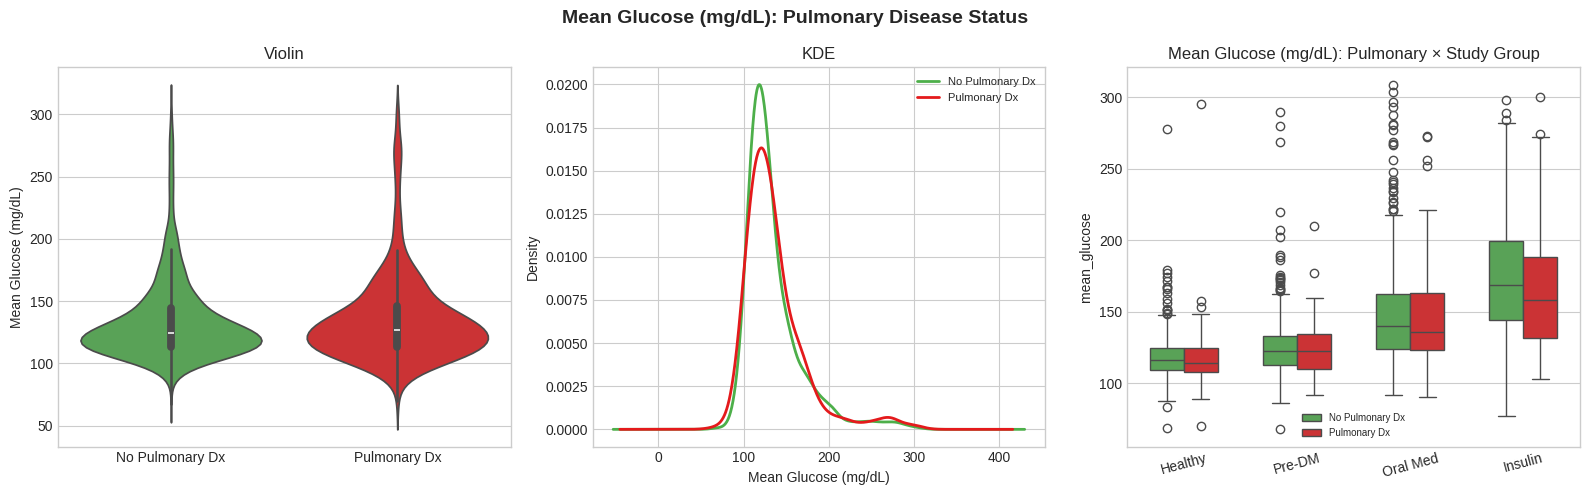

mean_glucose: No pulm=134.71  Pulm=136.22  d=+0.043  p=0.4537  ns


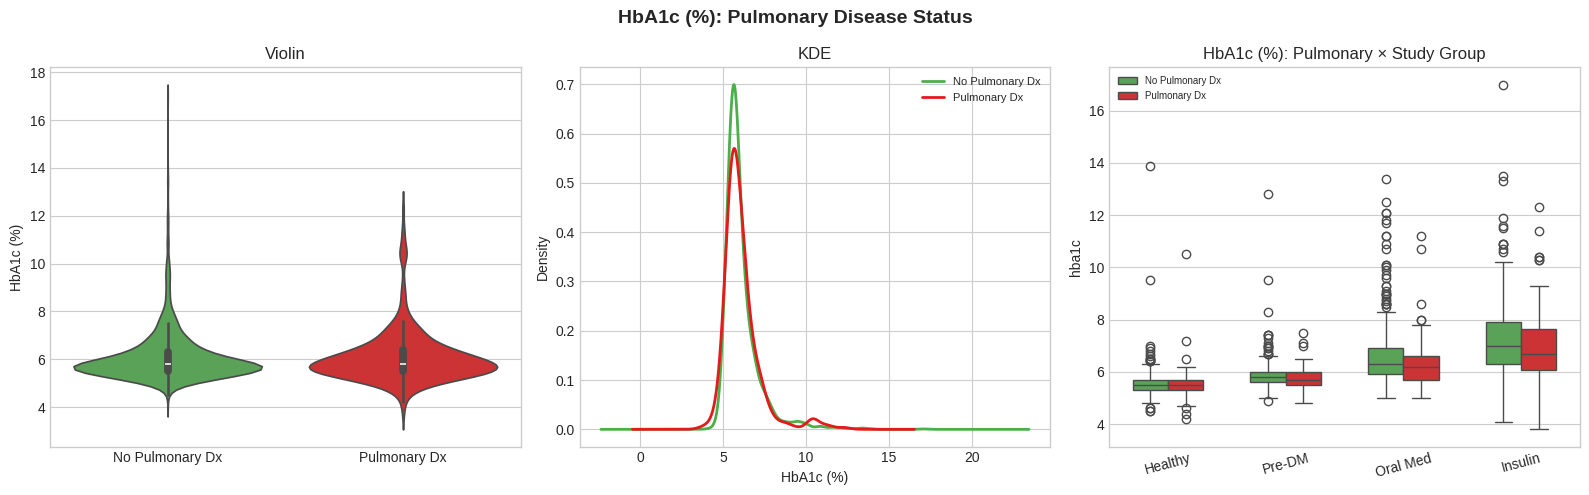

hba1c: No pulm=6.12  Pulm=6.12  d=+0.001  p=0.9605  ns


In [14]:
# ── 4a. Pulmonary × mean_glucose and HbA1c distributions ──────────
if plm_flag is not None:
    PLM_ORDER = ['No Pulmonary Dx', 'Pulmonary Dx']
    PLM_PAL   = {'No Pulmonary Dx': '#4daf4a', 'Pulmonary Dx': '#e41a1c'}

    for outcome, ylabel in [('mean_glucose', 'Mean Glucose (mg/dL)'), ('hba1c', 'HbA1c (%)')]:
        sub = df.dropna(subset=[outcome, 'pulmonary_label'])
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(f'{ylabel}: Pulmonary Disease Status', fontsize=14, fontweight='bold')

        sns.violinplot(data=sub, x='pulmonary_label', y=outcome,
                       order=PLM_ORDER, palette=PLM_PAL, inner='box', ax=axes[0])
        axes[0].set_title('Violin'); axes[0].set_xlabel(''); axes[0].set_ylabel(ylabel)

        for lbl in PLM_ORDER:
            sub[sub['pulmonary_label'] == lbl][outcome].plot.kde(
                ax=axes[1], label=lbl, linewidth=2, color=PLM_PAL[lbl])
        axes[1].set_title('KDE'); axes[1].set_xlabel(ylabel); axes[1].legend(fontsize=8)

        sns.boxplot(data=sub, x='study_group_label', y=outcome,
                    hue='pulmonary_label',
                    order=STUDY_GROUP_ORDER, hue_order=PLM_ORDER,
                    palette=PLM_PAL, width=0.6, ax=axes[2])
        axes[2].set_title(f'{ylabel}: Pulmonary × Study Group')
        axes[2].set_xlabel(''); axes[2].legend(title='', fontsize=7)
        axes[2].tick_params(axis='x', rotation=15)

        plt.tight_layout()
        plt.show()

        # Overall Mann-Whitney
        s0 = sub[sub[PLM_COL] == 0][outcome]
        s1 = sub[sub[PLM_COL] == 1][outcome]
        if len(s0) > 5 and len(s1) > 5:
            u, p = stats.mannwhitneyu(s0, s1, alternative='two-sided')
            d    = (s1.mean() - s0.mean()) / np.sqrt((s0.std(ddof=1)**2 + s1.std(ddof=1)**2) / 2)
            sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
            print(f'{outcome}: No pulm={s0.mean():.2f}  Pulm={s1.mean():.2f}  '
                  f'd={d:+.3f}  p={p:.4f}  {sig}')

In [15]:
# ── 4b. Within-group: pulmonary vs non-pulmonary ───────────────────
if plm_flag is not None:
    print('=== Within-Group: Pulmonary vs Non-Pulmonary ===\n')
    for outcome in ['mean_glucose', 'hba1c', 'tir', 'glucose_cv']:
        if outcome not in df.columns:
            continue
        print(f'--- {outcome} ---')
        print(f'{"Study Group":<12}  {"No Pulm":>10}  {"Pulm":>10}  {"diff":>8}  {"p":>8}  sig')
        print('-' * 60)
        for grp in STUDY_GROUP_ORDER:
            sub = df[df['study_group_label'] == grp].dropna(
                subset=[outcome, PLM_COL])
            s0  = sub[sub[PLM_COL] == 0][outcome]
            s1  = sub[sub[PLM_COL] == 1][outcome]
            if len(s0) < 5 or len(s1) < 5:
                continue
            u, p = stats.mannwhitneyu(s0, s1, alternative='two-sided')
            diff = s1.mean() - s0.mean()
            sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
            print(f'{grp:<12}  {s0.mean():>10.2f}  {s1.mean():>10.2f}  {diff:>+8.2f}  {p:>8.4f}  {sig}')
        print()

=== Within-Group: Pulmonary vs Non-Pulmonary ===

--- mean_glucose ---
Study Group      No Pulm        Pulm      diff         p  sig
------------------------------------------------------------
Healthy           117.87      118.69     +0.81    0.3830  ns
Pre-DM            125.92      123.65     -2.26    0.4442  ns
Oral Med          147.84      144.71     -3.12    0.3753  ns
Insulin           175.87      168.43     -7.44    0.1871  ns

--- hba1c ---
Study Group      No Pulm        Pulm      diff         p  sig
------------------------------------------------------------
Healthy             5.54        5.54     +0.00    0.5600  ns
Pre-DM              5.85        5.80     -0.05    0.2298  ns
Oral Med            6.59        6.32     -0.26    0.0133  *
Insulin             7.41        7.22     -0.19    0.2880  ns



## Section 5: Pulmonary × Diabetes Management Quality

Focused on Oral Med + Insulin groups — the participants actively managing diabetes.
Tests boss task #8: does having pulmonary disease change how well diabetes is managed?

In [16]:
# ── 5. Management metrics: pulmonary vs non-pulmonary (medicated) ──
MGMT_COLS = [
    ('dml_gap_physical_activity',  'Physical Activity Gap'),
    ('dml_gap_medication_mgmt',    'Medication Management Gap'),
    ('dml_gap_composite',          'DML Composite Gap'),
    ('paid_total',                 'PAID-5 Diabetes Distress'),
    ('average_daily_activity',     'Avg Daily Activity (wearable)'),
    ('average_oxygen_saturation_pct', 'Avg SpO2 (%)'),
]

if plm_flag is not None:
    medicated = df[df['study_group_label'].isin(['Oral Med', 'Insulin'])].copy()

    BONF_A = 0.05 / len(MGMT_COLS)
    print(f'=== Management: Pulmonary vs Non-Pulmonary (Oral Med + Insulin) ===')
    print(f'Bonferroni alpha = {BONF_A:.4f}  ({len(MGMT_COLS)} metrics)\n')
    print(f'{"Metric":<40}  {"No Pulm":>10}  {"Pulm":>10}  {"d":>7}  {"p":>8}  sig')
    print('-' * 90)

    mgmt_rows = []
    for col, label in MGMT_COLS:
        if col not in medicated.columns:
            continue
        sub = medicated.dropna(subset=[col, PLM_COL])
        s0  = sub[sub[PLM_COL] == 0][col]
        s1  = sub[sub[PLM_COL] == 1][col]
        if len(s0) < 5 or len(s1) < 5:
            continue
        u, p = stats.mannwhitneyu(s0, s1, alternative='two-sided')
        d    = (s1.mean() - s0.mean()) / np.sqrt((s0.std(ddof=1)**2 + s1.std(ddof=1)**2) / 2)
        sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        bonf = '← BONF' if p < BONF_A else ''
        print(f'{label:<40}  {s0.mean():>10.3f}  {s1.mean():>10.3f}  {d:>+7.3f}  {p:>8.4f}  {sig} {bonf}')
        mgmt_rows.append({
            'metric': label, 'col': col,
            'mean_no_pulm': round(s0.mean(), 3),
            'mean_pulm': round(s1.mean(), 3),
            'diff': round(s1.mean() - s0.mean(), 3),
            'cohens_d': round(d, 4), 'p': round(p, 5), 'sig': sig,
            'bonf_sig': p < BONF_A,
            'n_no_pulm': len(s0), 'n_pulm': len(s1)
        })

    mgmt_df = pd.DataFrame(mgmt_rows)

=== Management: Pulmonary vs Non-Pulmonary (Oral Med + Insulin) ===
Bonferroni alpha = 0.0083  (6 metrics)

Metric                                       No Pulm        Pulm        d         p  sig
------------------------------------------------------------------------------------------
Physical Activity Gap                          3.090      -0.083   -0.085    0.0111  * 
Medication Management Gap                     -6.699      -5.014   +0.024    0.2990  ns 
DML Composite Gap                              0.572       0.759   +0.008    0.2535  ns 
PAID-5 Diabetes Distress                       4.765       5.248   +0.104    0.1616  ns 


## Section 6: Pulmonary × SDOH

In [17]:
# ── 6. Pulmonary × SDOH interactions ─────────────────────────────
if plm_flag is not None:
    SDOH_COLS = [
        ('food_housing_insecurity',  'Food/Housing Insecurity'),
        ('discrimination_score',     'Discrimination Score'),
        ('neighborhood_safety_score','Neighborhood Safety'),
        ('healthcare_access_barriers','Healthcare Barriers'),
    ]

    # Chi-square: pulmonary × food/housing insecurity
    if 'food_housing_insecurity' in df.columns:
        ct = pd.crosstab(df[PLM_COL].map({0.0: 'No Pulm', 1.0: 'Pulm'}),
                         df['food_housing_insecurity'].map({0.0: 'Secure', 1.0: 'Insecure'}))
        if ct.min().min() >= 5:
            chi2, p, *_ = stats.chi2_contingency(ct)
            print('=== Pulmonary × Food/Housing Insecurity (Chi-square) ===')
            print(ct)
            print(f'chi2={chi2:.3f}  p={p:.4e}')

    # Continuous SDOH correlates
    print('\n=== SDOH Predictors of Pulmonary Disease Flag (Spearman) ===')
    for col, label in SDOH_COLS:
        if col not in df.columns:
            continue
        sub = df[[PLM_COL, col]].dropna()
        if len(sub) < 30:
            continue
        rho, p = stats.spearmanr(sub[PLM_COL], sub[col])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'  {label:<30}: rho={rho:+.4f}  p={p:.4e}  {sig}')

    # 3-way: pulmonary × insecurity × mean_glucose within Oral Med
    if 'food_housing_insecurity' in df.columns:
        print('\n=== 3-way: Pulmonary × Insecurity × Mean Glucose (Oral Med only) ===')
        oral = df[df['study_group_label'] == 'Oral Med']
        for plm, ins in [(0, 0), (0, 1), (1, 0), (1, 1)]:
            sub = oral[(oral[PLM_COL] == plm) &
                       (oral['food_housing_insecurity'] == ins)]
            g = sub['mean_glucose'].dropna()
            print(f'  Pulm={plm} Insec={ins}: n={len(g):3d}  mean={g.mean():.1f}  SD={g.std():.1f}')

=== Pulmonary × Food/Housing Insecurity (Chi-square) ===
food_housing_insecurity  Insecure  Secure
mhoccur_plm                              
No Pulm                      1137     751
Pulm                          187     107
chi2=1.083  p=2.9813e-01

=== SDOH Predictors of Pulmonary Disease Flag (Spearman) ===
  Food/Housing Insecurity       : rho=+0.0236  p=2.6953e-01  ns
  Discrimination Score          : rho=+0.0308  p=1.5103e-01  ns
  Neighborhood Safety           : rho=-0.0212  p=3.3627e-01  ns
  Healthcare Barriers           : rho=+0.0450  p=3.5649e-02  *

=== 3-way: Pulmonary × Insecurity × Mean Glucose (Oral Med only) ===
  Pulm=0 Insec=0: n=209  mean=152.4  SD=36.2
  Pulm=0 Insec=1: n=344  mean=145.0  SD=35.1
  Pulm=1 Insec=0: n= 40  mean=147.7  SD=31.7
  Pulm=1 Insec=1: n= 61  mean=142.7  SD=35.0


## Section 7: Literature Alignment Note

**Known asthma–diabetes comorbidity mechanisms (clinical context for AI-READI findings):**

1. **Corticosteroid effect**: Inhaled corticosteroids (ICS) used to treat asthma — especially high-dose ICS — raise blood glucose by promoting gluconeogenesis and reducing insulin sensitivity. Oral corticosteroids (for exacerbations) cause acute hyperglycemia. This would predict *higher* glucose in pulmonary patients, particularly in medicated groups.

2. **Beta-agonist effect**: Short-acting beta-agonists (albuterol) and long-acting beta-agonists (LABAs) increase glycogenolysis, raising blood glucose acutely. Chronic use may impair insulin secretion.

3. **Shared inflammatory pathways**: Both asthma and T2D involve systemic low-grade inflammation (IL-6, TNF-α, IL-17). In T2D, adipose tissue inflammation promotes insulin resistance; in asthma, airway inflammation and systemic IL-6 may further impair insulin sensitivity.

4. **Physical activity limitation**: Asthma limits exercise capacity, which may reduce physical activity levels and worsen glucose metabolism — particularly for T2D management where exercise is a key therapeutic tool.

5. **Obesity bridge**: Obesity is a major risk factor for both asthma (adipose tissue generates pro-inflammatory cytokines affecting airways) and T2D. The overlap in AI-READI may partly reflect this shared upstream risk factor.

In [18]:
# ── Summary table & export ─────────────────────────────────────────
if plm_flag is not None:
    summary_rows = []
    for grp in ['All'] + STUDY_GROUP_ORDER:
        sub = df if grp == 'All' else df[df['study_group_label'] == grp]
        for pulm_val, pulm_label in [(0, 'No Pulmonary'), (1, 'Pulmonary')]:
            s = sub[sub[PLM_COL] == pulm_val]
            if len(s) < 5:
                continue
            row = {'study_group': grp, 'pulmonary_status': pulm_label, 'n': len(s)}
            for col in ['mean_glucose', 'hba1c', 'tir', 'glucose_cv',
                        'dml_gap_physical_activity', 'paid_total']:
                if col in s.columns:
                    row[f'{col}_mean'] = round(s[col].mean(), 3)
            summary_rows.append(row)

    summary_df = pd.DataFrame(summary_rows)
    print(summary_df.to_string(index=False))

    summary_df.to_csv(out_dir / '24_pulmonary_diabetes_summary.csv', index=False)
    if 'mgmt_df' in dir():
        mgmt_df.to_csv(out_dir / '24_pulmonary_management_metrics.csv', index=False)
    print('\nSaved 24_pulmonary_diabetes_summary.csv')

study_group pulmonary_status    n  mean_glucose_mean  hba1c_mean  dml_gap_physical_activity_mean  paid_total_mean
        All     No Pulmonary 1888            134.708       6.119                           2.201            3.910
        All        Pulmonary  294            136.221       6.120                           0.493            4.161
    Healthy     No Pulmonary  667            117.873       5.537                           1.389            2.552
    Healthy        Pulmonary   81            118.688       5.540                          -2.156            2.117
     Pre-DM     No Pulmonary  471            125.916       5.854                           1.935            4.458
     Pre-DM        Pulmonary   68            123.652       5.801                           4.877            4.224
   Oral Med     No Pulmonary  553            147.836       6.587                           3.376            4.454
   Oral Med        Pulmonary  101            144.713       6.323                        

## Key Findings

### Comorbidity Prevalence (Section 1)

Top 10 conditions by overall prevalence in AI-READI (n=2,280):

| Condition | Overall | Healthy | Pre-DM | Oral Med | Insulin |
|-----------|---------|---------|--------|----------|---------|
| High Cholesterol | 51.1% | 38.4% | 48.8% | 63.4% | 61.2% |
| Hypertension | 50.7% | 32.7% | 46.6% | 65.6% | 74.4% |
| Rheumatoid Arthritis | 41.8% | 33.4% | 41.6% | 48.1% | 50.4% |
| Obesity | 38.6% | 25.3% | 38.2% | 48.4% | 53.1% |
| Dry Eye | 32.9% | 28.6% | 34.6% | 35.3% | 35.7% |
| Cataracts | 31.0% | 27.7% | 27.9% | 33.2% | 41.5% |
| GI Disorder | 23.1% | 20.7% | 20.9% | 26.4% | 26.4% |
| Urinary Disorder | 23.1% | 20.1% | 24.3% | 24.8% | 24.8% |

Diabetes-specific complications show the steepest severity gradients:
- **Diabetic Retinopathy**: 0.4% (Healthy) → 22.1% (Insulin)
- **Renal Disease**: 5.4% → 27.1%
- **Myocardial Infarction**: 2.8% → 13.6%
- **Glaucoma**: 6.4% → 19.0%

These gradients confirm that the Insulin group carries a substantially higher systemic disease burden across virtually every condition tracked.

---

### Co-Occurrence Matrix (Section 2)

Top disease pairs within the Insulin group:

| Pair | Co-occurrence |
|------|---------------|
| High Cholesterol + Hypertension | 52.7% |
| Hypertension + Obesity | 41.1% |
| Hypertension + Rheumatoid Arthritis | 40.7% |
| High Cholesterol + Obesity | 35.3% |
| High Cholesterol + Rheumatoid Arthritis | 34.9% |
| Hypertension + Cataracts | 34.9% |
| Hypertension + Renal Disease | 23.3% |

The Phi-coefficient co-occurrence matrix confirms that High Cholesterol, Hypertension, and Obesity form a dense cardiometabolic cluster — consistent with the NB11 comorbidity cluster findings. Renal disease co-occurs significantly with Hypertension (23.3%) and Diabetic Retinopathy, reflecting shared microvascular disease progression.

---

### ⚠ Pulmonary/Asthma Verification — Critical Finding (Section 3)

- `mhoccur_plm` prevalence: **13.6% overall** (311 / 2,280); Healthy 11.3% → Insulin 17.4%; chi-square trend p=0.025*
- Asthma ICD-10 codes (J45.x) in `condition_occurrence.csv`: **0 participants matched**
- Asthma SNOMED codes: **0 participants matched**
- Overlap between `mhoccur_plm` flag and confirmed asthma diagnosis: **0%**

**`mhoccur_plm` is NOT an asthma proxy.** It is a self-reported flag for "Chronic pulmonary (lung) problems" capturing the full spectrum of lung conditions — COPD, restrictive lung disease, chronic bronchitis, pulmonary fibrosis, and others — as confirmed by the `condition_source_value` label in `condition_occurrence.csv`. **Any prior or future interpretation of this variable as an asthma measure must be corrected.** The variable should be referred to as "pulmonary disease" throughout the report.

---

### Pulmonary × Glycemic Outcomes (Section 4)

Overall: **no significant difference** in mean glucose or HbA1c between pulmonary and non-pulmonary participants at the full-cohort level.

Within-group HbA1c (notable finding):
- **Oral Med**: Pulmonary 6.32% vs No Pulmonary 6.59%, diff=−0.26%, p=0.013* — pulmonary patients have paradoxically *lower* HbA1c
- Healthy, Pre-DM, Insulin: all ns

This paradoxical lower HbA1c in Oral Med pulmonary patients mirrors the insecurity reversal seen in NB22. It may reflect caloric restriction (reduced appetite from pulmonary disease), medication interactions, or selection effects.

---

### Pulmonary × Diabetes Management Quality (Section 5)

Among medicated patients (Oral Med + Insulin only), Bonferroni α=0.0083:

| Metric | No Pulmonary | Pulmonary | Cohen's d | p | sig |
|--------|-------------|-----------|-----------|---|-----|
| Physical Activity Gap | 3.090 | −0.083 | −0.085 | 0.011 | * |
| Medication Management Gap | −6.699 | −5.014 | +0.024 | 0.299 | ns |
| DML Composite Gap | 0.572 | 0.759 | +0.008 | 0.254 | ns |
| PAID-5 (Diabetes Distress) | 4.765 | 5.248 | +0.104 | 0.162 | ns |

The physical activity gap is significantly lower (i.e., less of a deficit) in pulmonary patients (p=0.011) — though this does not survive Bonferroni correction. Counterintuitively, pulmonary patients have a *smaller* physical activity management gap, suggesting either (a) they are reporting realistic self-assessment of their activity limitations, or (b) the wearable-based activity gap calculation behaves differently for this population. No significant differences in medication management, composite DML, or diabetes distress.

---

### Pulmonary × SDOH (Section 6)

- Food/housing insecurity: pulmonary vs non-pulmonary chi-square p=0.298 ns — pulmonary disease is not significantly associated with food/housing insecurity
- Healthcare barriers: rho=+0.045, p=0.036* (weak but significant)
- All other SDOH metrics (discrimination, neighborhood safety, insecurity): ns

3-way interaction (Pulmonary × Insecurity × Mean Glucose, Oral Med only):

| Pulmonary | Insecure | n | Mean Glucose |
|-----------|----------|---|--------------|
| No | Secure | 209 | 152.4 |
| No | Insecure | 344 | 145.0 |
| Yes | Secure | 40 | 147.7 |
| Yes | Insecure | 61 | 142.7 |

The insecurity reversal (lower glucose in insecure patients) persists regardless of pulmonary status. Pulmonary disease adds a modest further reduction but does not drive the effect — the two factors appear independent.

---

### Literature Alignment (Section 7)

AI-READI findings are **inconsistent with the corticosteroid hyperglycemia hypothesis**: if ICS/OCS use in pulmonary patients were a significant driver, we would expect *higher* glucose in pulmonary participants, particularly in medicated groups. Instead, glucose is equivalent or slightly lower. The activity limitation hypothesis is partially supported by the physical activity gap finding, but the effect is small and does not survive Bonferroni correction. The most likely explanation for the null glycemic difference is that AI-READI's `mhoccur_plm` captures a heterogeneous mix of lung conditions — including many stable, mild cases — rather than active severe asthma or COPD requiring high-dose corticosteroids.